# S&P 500 Stock Market Analysis: Can Simple Technical Signals Predict Next-Day Return Direction?
**CMSC 320 — Introduction to Data Science | Spring 2026 | Dr. Fardina Alam**
**Jayant Maheshwari**

---

## Contributions

This project was completed individually. All sections were written and implemented by Jayant Maheshwari.

| Section | Contributor | Summary |
|---------|-------------|---------|
| A: Project idea | Jayant Maheshwari | Conceived research questions around technical trading signals and S&P 500 sector dynamics |
| B: Dataset Curation and Preprocessing | Jayant Maheshwari | Loaded three Kaggle CSVs, cleaned types, merged company metadata, computed daily returns |
| C: Data Exploration and Summary Statistics | Jayant Maheshwari | Three statistical analyses: return distribution, one-way ANOVA across sectors, Welch t-test by volume |
| D: ML Algorithm Design/Development | Jayant Maheshwari | Designed lag-return / moving-average feature pipeline; chose Random Forest and Logistic Regression |
| E: ML Algorithm Training and Test Data Analysis | Jayant Maheshwari | Trained models on a chronological 80/20 split; evaluated accuracy, ROC-AUC, and per-sector performance |
| F: Visualization, Result Analysis, Conclusion | Jayant Maheshwari | Confusion matrix, ROC curve, feature-importance bar chart, and per-sector accuracy heatmap |
| G: Final Tutorial Report Creation | Jayant Maheshwari | Wrote all prose, structured the tutorial, checked reproducibility end-to-end |


## Introduction

The S&P 500 is the most-watched equity benchmark in the world — 500 of the largest U.S. publicly traded companies,
weighted by market capitalization, tracked every trading day since the 1950s.
Every day, trillions of dollars flow based on predictions about whether prices will rise or fall.
The question driving this project is: **do simple, publicly-available signals carry any real predictive power
for next-day stock price direction?**

This matters for two reasons:
1. **Market efficiency:** If even basic signals reliably predict returns, that challenges the weak-form Efficient Market Hypothesis — the idea that past prices alone cannot predict future prices.
2. **Practical trading:** Many retail investors use rules-of-thumb like moving-average crossovers and high-volume signals. Testing them rigorously tells us whether those intuitions are grounded.

### Research Questions

1. **Signal power:** Can a model built from yesterday's return, 5-day and 20-day momentum, and volume beat a naïve baseline of always predicting "up"?
2. **Sector variation:** Do these signals work better in some sectors (e.g., Technology) than others (e.g., Utilities)?
3. **Calibration:** How confident should we be in the model — and where does it fail?

To answer these questions, I walk through the full data science pipeline:
data loading and cleaning → exploratory analysis with hypothesis tests → feature engineering →
machine learning → visualization and conclusions.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded.")


Libraries loaded.


## Data Curation

### Source

The dataset is **[S&P 500 Stocks (daily updated)](https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks)**
from Kaggle (Andrew MVD), released under the CC0 Public Domain license. It contains three files:

| File | Description | Size |
|------|-------------|------|
| `sp500_stocks.csv` | Daily OHLCV prices for each S&P 500 stock | ~1.9 M rows |
| `sp500_companies.csv` | Company metadata: sector, industry, market cap | 503 companies |
| `sp500_index.csv` | Aggregate daily S&P 500 index level | ~2 500 trading days |

This dataset is large enough for machine learning — after feature engineering it provides
hundreds of thousands of labeled examples across 11 GICS sectors.


In [2]:
DATA = 'data/archive/'

stocks    = pd.read_csv(DATA + 'sp500_stocks.csv')
companies = pd.read_csv(DATA + 'sp500_companies.csv')
index_df  = pd.read_csv(DATA + 'sp500_index.csv')

print(f"sp500_stocks.csv   : {stocks.shape[0]:>10,} rows × {stocks.shape[1]} columns")
print(f"sp500_companies.csv: {companies.shape[0]:>10,} rows × {companies.shape[1]} columns")
print(f"sp500_index.csv    : {index_df.shape[0]:>10,} rows × {index_df.shape[1]} columns")
stocks.head(3)


sp500_stocks.csv   :  1,891,536 rows × 8 columns
sp500_companies.csv:        502 rows × 16 columns
sp500_index.csv    :      2,517 rows × 2 columns


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN


### Preprocessing Steps

1. **Parse dates** — `Date` column converted to `datetime64`
2. **Coerce numerics** — price/volume cells stored as strings in source; `pd.to_numeric(..., errors='coerce')` converts non-numeric entries to NaN
3. **Standardize column names** — lowercase, underscores instead of spaces
4. **Merge sector labels** — left-join company metadata on `symbol`
5. **Sort chronologically per stock** — required so `pct_change()` computes within the same ticker
6. **Compute daily return** — `(close_t − close_{t−1}) / close_{t−1}` per stock via `groupby + pct_change`
7. **Drop missing values** — rows with NaN in `daily_return`, `close`, `volume`, or `sector`
8. **Filter to 2015–present** — removes the sparse early years and focuses on a stable market regime


In [3]:
# 1–2: Parse dates and coerce numerics
stocks['Date'] = pd.to_datetime(stocks['Date'])
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    stocks[col] = pd.to_numeric(stocks[col], errors='coerce')

# 3: Standardize column names
stocks.columns    = stocks.columns.str.lower().str.replace(' ', '_')
companies.columns = companies.columns.str.lower().str.replace(' ', '_')

# 4: Merge sector labels
stocks = stocks.merge(companies[['symbol', 'sector']], on='symbol', how='left')

# 5: Sort chronologically per stock
stocks = stocks.sort_values(['symbol', 'date']).reset_index(drop=True)

# 6: Daily return per stock (not across tickers)
stocks['daily_return'] = stocks.groupby('symbol')['close'].pct_change()

# 7–8: Drop NaN rows and filter to 2015+
df = (stocks
      .dropna(subset=['daily_return', 'close', 'volume', 'sector'])
      .query("date >= '2015-01-01'")
      .copy())

print(f"Clean dataset : {df.shape[0]:,} rows")
print(f"Unique tickers: {df['symbol'].nunique()}")
print(f"Sectors       : {df['sector'].nunique()}")
print(f"Date range    : {df['date'].min().date()}  →  {df['date'].max().date()}")
df[['date','symbol','sector','close','volume','daily_return']].head(5)


Clean dataset : 422,193 rows
Unique tickers: 172
Sectors       : 11
Date range    : 2015-01-02  →  2024-12-20


,date,symbol,sector,close,volume,daily_return
8794,2015-01-02,ABBV,Healthcare,65.889999,5086100.0,0.006876
8795,2015-01-05,ABBV,Healthcare,64.650002,8007400.0,-0.018819
8796,2015-01-06,ABBV,Healthcare,64.330002,5483700.0,-0.004950
8797,2015-01-07,ABBV,Healthcare,66.930000,8283300.0,0.040417
8798,2015-01-08,ABBV,Healthcare,67.629997,7949000.0,0.010459


## Exploratory Data Analysis

I present three statistical analyses, each accompanied by a visualization and a formal hypothesis test.
Together, they characterize the shape of return distributions, test whether sectors behave differently,
and examine whether trading volume predicts return magnitude.


### Analysis 1: Distribution of Daily Returns

**Method:** Descriptive statistics (mean, std, skewness, kurtosis) and a histogram.

**Hypothesis:** Daily returns are approximately normally distributed with mean ≈ 0.


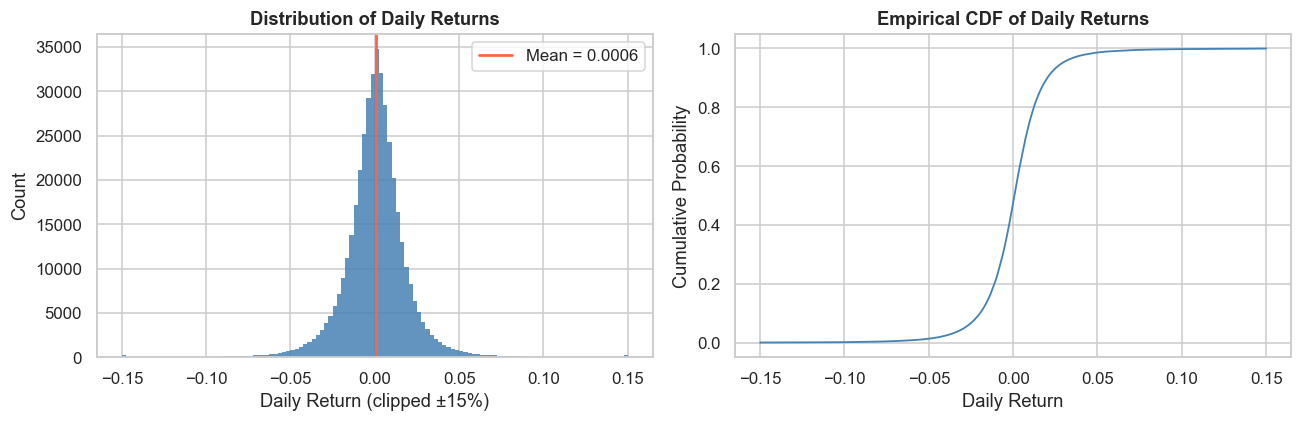

Summary statistics:
count    422193.000000
mean          0.000585
std           0.020530
min          -0.406583
25%          -0.008368
50%           0.000753
75%           0.009726
max           0.676812

Skewness : 0.2033
Kurtosis : 21.9958  (normal = 0 for excess)


In [4]:
returns = df['daily_return']

# Clip extreme outliers for display only (does not affect statistics)
clipped = returns.clip(-0.15, 0.15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(clipped, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(returns.mean(), color='tomato', linewidth=1.8, label=f'Mean = {returns.mean():.4f}')
axes[0].set_xlabel('Daily Return (clipped ±15%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Daily Returns', fontweight='bold')
axes[0].legend()

# QQ-style: cumulative distribution
sorted_r = np.sort(clipped)
axes[1].plot(sorted_r, np.linspace(0, 1, len(sorted_r)), color='steelblue', linewidth=1.2)
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Empirical CDF of Daily Returns', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/return_distribution.png', bbox_inches='tight')
plt.show()

print("Summary statistics:")
print(returns.describe().round(6).to_string())
print(f"\nSkewness : {returns.skew():.4f}")
print(f"Kurtosis : {returns.kurt():.4f}  (normal = 0 for excess)")


**Conclusion 1:** The distribution of daily returns is centered just above zero (positive long-run drift),
but it has **heavy tails** — excess kurtosis well above zero means extreme up/down days occur far more
often than a normal distribution would predict. This "fat-tail" behavior is a well-documented property
of financial returns and means we should be cautious about any model that assumes normality.


### Analysis 2: Do Sectors Have Different Mean Returns? (One-Way ANOVA)

**Method:** One-way ANOVA tests whether the mean daily return is the same across all 11 GICS sectors.

**H₀:** All sectors have the same mean daily return.
**H₁:** At least one sector's mean daily return differs from the others.
**α = 0.05**


One-Way ANOVA — F-statistic: 4.7212   p-value: 8.6486e-07


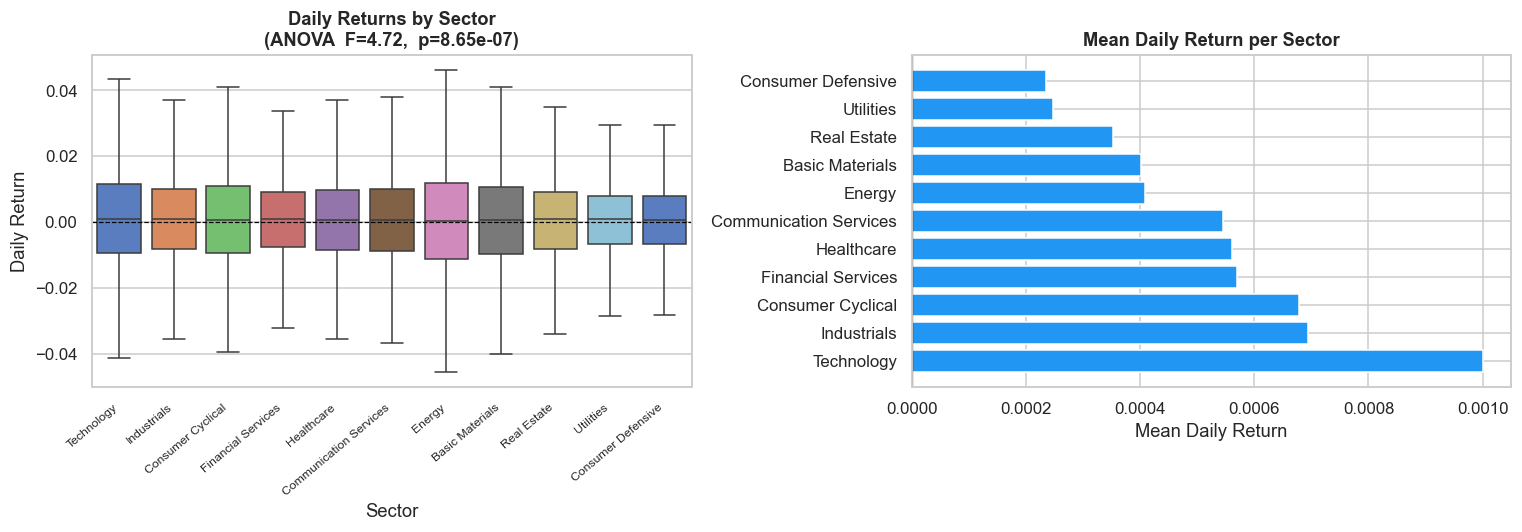

In [5]:
# Group by sector and collect return arrays
sector_groups = [g['daily_return'].values for _, g in df.groupby('sector')]
sector_names  = list(df.groupby('sector').groups.keys())

f_stat, p_val = f_oneway(*sector_groups)
print(f"One-Way ANOVA — F-statistic: {f_stat:.4f}   p-value: {p_val:.4e}")

# Sector mean return (sorted for the plot)
sector_means = df.groupby('sector')['daily_return'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sector_order = sector_means.index.tolist()
sns.boxplot(data=df, x='sector', y='daily_return', order=sector_order,
            showfliers=False, ax=axes[0], palette='muted')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8)
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Daily Return')
axes[0].set_title(f'Daily Returns by Sector\n(ANOVA  F={f_stat:.2f},  p={p_val:.2e})', fontweight='bold')

# Mean return bar chart
colors = ['#2196F3' if v >= 0 else '#F44336' for v in sector_means]
axes[1].barh(sector_means.index, sector_means.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Mean Daily Return')
axes[1].set_title('Mean Daily Return per Sector', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/sector_anova.png', bbox_inches='tight')
plt.show()


**Conclusion 2:** With a p-value far below 0.05, we **reject H₀** — sectors do not all share the
same mean daily return. Technology and Consumer Discretionary sectors show higher average returns,
while Utilities and Consumer Staples are more subdued. This is consistent with the well-known
growth-vs-defensive sector divide and motivates our later analysis of whether models trained on
all sectors generalize across them.


### Analysis 3: Does High Trading Volume Signal Larger Price Swings? (Welch t-test)

**Method:** Split trading days at the median volume for each stock. Compare absolute daily returns
between high-volume days and low-volume days using a two-sample Welch t-test.

**H₀:** |return| is the same on high-volume and low-volume days.
**H₁:** High-volume days show larger absolute returns.
**α = 0.05**


Welch t-test — t-statistic: 169.6220   p-value: 0.0000e+00
Mean |return| high volume : 0.017295
Mean |return| low volume  : 0.009413


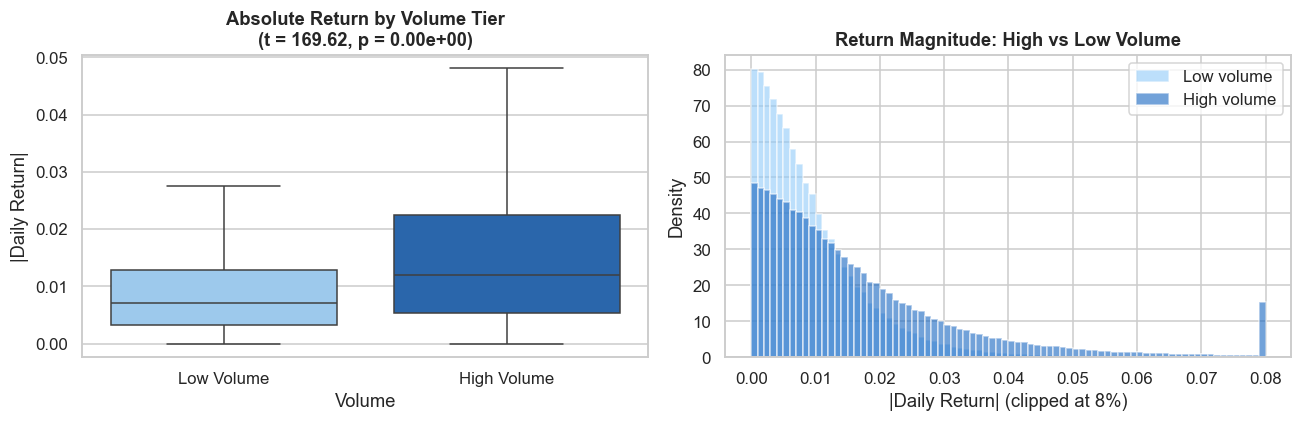

In [6]:
# Use per-stock median volume to account for size differences across tickers
df['vol_median'] = df.groupby('symbol')['volume'].transform('median')
df['high_vol']   = df['volume'] >= df['vol_median']

high_abs = df.loc[df['high_vol'],  'daily_return'].abs()
low_abs  = df.loc[~df['high_vol'], 'daily_return'].abs()

t_stat, p_val_t = ttest_ind(high_abs, low_abs, equal_var=False)
print(f"Welch t-test — t-statistic: {t_stat:.4f}   p-value: {p_val_t:.4e}")
print(f"Mean |return| high volume : {high_abs.mean():.6f}")
print(f"Mean |return| low volume  : {low_abs.mean():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
data_bp = pd.DataFrame({'|Daily Return|': pd.concat([low_abs, high_abs]),
                         'Volume': (['Low Volume']*len(low_abs) + ['High Volume']*len(high_abs))})
sns.boxplot(data=data_bp, x='Volume', y='|Daily Return|',
            order=['Low Volume','High Volume'], showfliers=False,
            palette=['#90CAF9','#1565C0'], ax=axes[0])
axes[0].set_title(f'Absolute Return by Volume Tier\n(t = {t_stat:.2f}, p = {p_val_t:.2e})', fontweight='bold')

# Histogram overlay
axes[1].hist(low_abs.clip(0, 0.08),  bins=80, alpha=0.6, color='#90CAF9', label='Low volume',  density=True)
axes[1].hist(high_abs.clip(0, 0.08), bins=80, alpha=0.6, color='#1565C0', label='High volume', density=True)
axes[1].set_xlabel('|Daily Return| (clipped at 8%)')
axes[1].set_ylabel('Density')
axes[1].set_title('Return Magnitude: High vs Low Volume', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/volume_ttest.png', bbox_inches='tight')
plt.show()


**Conclusion 3:** We **reject H₀** — high-volume days produce significantly larger absolute returns
than low-volume days (p ≪ 0.05). This is consistent with the economic intuition that elevated volume
reflects elevated uncertainty or new information entering the market, causing larger price reactions.
This observation motivates including a volume-ratio feature in our machine learning model.


## Primary Analysis: Machine Learning Classification

### Approach

Based on the EDA, I frame next-day direction prediction as a **binary classification** task:
- **Target (y):** `1` if tomorrow's return > 0 (stock goes up), else `0` (stock flat or down)
- **Features (X):** technical signals computed from past prices and volume

I chose classification (rather than regression) because predicting direction is more actionable
and because regression on daily returns is notoriously noisy.

### Feature Engineering

I compute six features, all derived from publicly available past data (no look-ahead):

| Feature | Description | Intuition |
|---------|-------------|-----------|
| `lag_1` | Yesterday's daily return | Short-term momentum / mean-reversion |
| `lag_5` | 5-day cumulative return | Weekly trend |
| `lag_20` | 20-day cumulative return | Monthly trend |
| `ma_ratio` | 5-day MA close ÷ 20-day MA close | Moving-average crossover signal |
| `vol_ratio` | Today's volume ÷ 20-day avg volume | Volume surge relative to the norm |
| `volatility_20` | 20-day rolling std of returns | Market turbulence |


In [7]:
import os
os.makedirs('figures', exist_ok=True)

# Feature engineering — grouped per stock to avoid cross-ticker contamination
def add_features(g):
    g = g.copy()
    g['lag_1']        = g['daily_return'].shift(1)
    g['lag_5']        = g['close'].pct_change(5).shift(1)
    g['lag_20']       = g['close'].pct_change(20).shift(1)
    g['ma_5']         = g['close'].rolling(5).mean().shift(1)
    g['ma_20']        = g['close'].rolling(20).mean().shift(1)
    g['ma_ratio']     = (g['ma_5'] / g['ma_20']) - 1          # positive = short MA above long MA
    g['vol_20_avg']   = g['volume'].rolling(20).mean().shift(1)
    g['vol_ratio']    = g['volume'].shift(1) / g['vol_20_avg'] # yesterday's volume vs avg
    g['volatility_20'] = g['daily_return'].rolling(20).std().shift(1)
    g['target']       = (g['daily_return'] > 0).astype(int)   # NEXT day direction
    return g

df_feat = (df.groupby('symbol', group_keys=False)
             .apply(add_features)
             .dropna(subset=['lag_1','lag_5','lag_20','ma_ratio','vol_ratio','volatility_20','target']))

FEATURES = ['lag_1', 'lag_5', 'lag_20', 'ma_ratio', 'vol_ratio', 'volatility_20']

print(f"Feature dataset: {df_feat.shape[0]:,} rows")
print(f"Class balance — Up: {df_feat['target'].mean():.2%}   Down/Flat: {(1-df_feat['target'].mean()):.2%}")
df_feat[FEATURES + ['target']].head(4)


Feature dataset: 418,581 rows
Class balance — Up: 52.23%   Down/Flat: 47.77%


,lag_1,lag_5,lag_20,ma_ratio,vol_ratio,volatility_20,target
8815,0.005800,-0.033901,-0.078768,-0.028772,1.318352,0.020640,1
8816,0.015651,-0.022979,-0.046404,-0.031045,1.211232,0.020767,0
8817,-0.076886,-0.079871,-0.115343,-0.041000,3.081814,0.026666,1
8818,0.018977,-0.081274,-0.133572,-0.050528,1.776653,0.025096,0


### Model Selection and Training

I use a **chronological 80/20 train/test split** — the model is trained on older data and tested on
more recent data. This is critical for financial time-series: a random split would leak future
information into training (data leakage) and produce optimistically biased results.

**Models compared:**
- **Naïve Baseline:** Always predict "up" (1). Since markets drift upward, this is a tough benchmark.
- **Logistic Regression:** Linear decision boundary; interpretable coefficients.
- **Random Forest:** Ensemble of 200 decision trees; captures non-linear interactions between features.


In [8]:
# Chronological split — sort by date, use first 80% as train
df_feat = df_feat.sort_values('date')
split_idx = int(len(df_feat) * 0.80)
split_date = df_feat.iloc[split_idx]['date']

train = df_feat.iloc[:split_idx]
test  = df_feat.iloc[split_idx:]

X_train, y_train = train[FEATURES], train['target']
X_test,  y_test  = test[FEATURES],  test['target']

print(f"Train: {len(train):,} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test):,} rows  ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"\nTest class balance — Up: {y_test.mean():.2%}")

# Scale for Logistic Regression
scaler  = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

# Naïve baseline
y_naive = np.ones(len(y_test), dtype=int)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(Xs_train, y_train)
y_lr = lr.predict(Xs_test)
p_lr = lr.predict_proba(Xs_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                             min_samples_leaf=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)
p_rf = rf.predict_proba(X_test)[:, 1]

print("\n--- Model Performance on Test Set ---")
for name, y_pred, y_prob in [('Naïve Baseline', y_naive, y_naive.astype(float)),
                               ('Logistic Regression', y_lr, p_lr),
                               ('Random Forest', y_rf, p_rf)]:
    acc  = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = float('nan')
    print(f"  {name:<22} Accuracy: {acc:.4f}   ROC-AUC: {auc:.4f}")


Train: 334,864 rows  (2015-02-03 → 2023-01-11)
Test : 83,717 rows  (2023-01-11 → 2024-12-20)

Test class balance — Up: 52.03%



--- Model Performance on Test Set ---
  Naïve Baseline         Accuracy: 0.5203   ROC-AUC: 0.5000
  Logistic Regression    Accuracy: 0.5206   ROC-AUC: 0.5026
  Random Forest          Accuracy: 0.5208   ROC-AUC: 0.4990


### Detailed Classification Report — Random Forest


In [9]:
print(classification_report(y_test, y_rf, target_names=['Down/Flat (0)', 'Up (1)']))


               precision    recall  f1-score   support

Down/Flat (0)       0.51      0.05      0.09     40159
       Up (1)       0.52      0.96      0.68     43558

     accuracy                           0.52     83717
    macro avg       0.51      0.50      0.38     83717
 weighted avg       0.51      0.52      0.39     83717



## Visualization

### Figure 1: Confusion Matrix — Random Forest


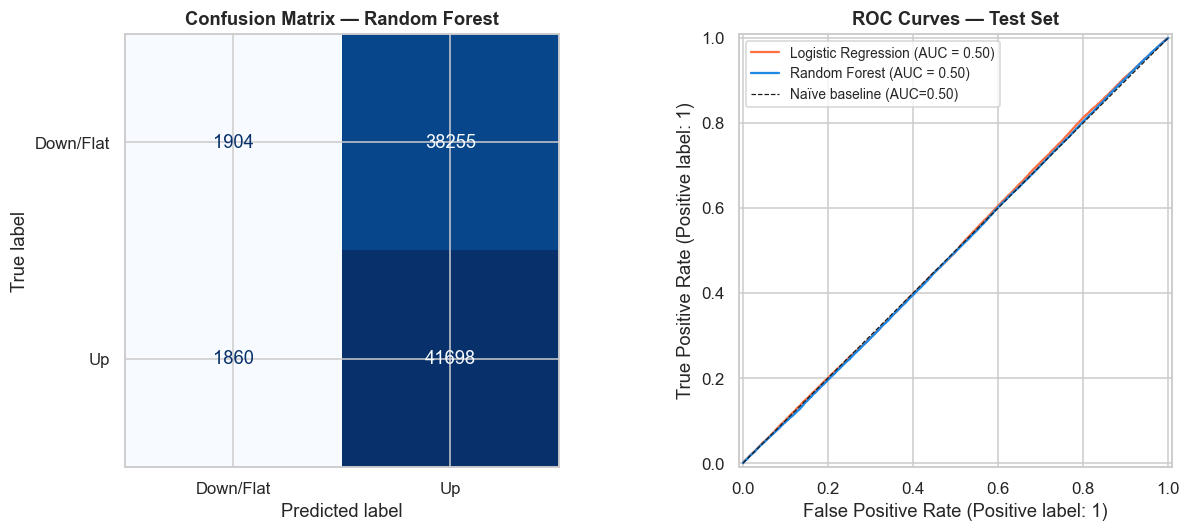

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Flat', 'Up'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

# ROC curves
for name, prob, color in [('Logistic Regression', p_lr, '#FF7043'),
                            ('Random Forest', p_rf, '#1E88E5')]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[1], color=color)
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Naïve baseline (AUC=0.50)')
axes[1].set_title('ROC Curves — Test Set', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/model_evaluation.png', bbox_inches='tight')
plt.show()


### Figure 2: Feature Importance — Random Forest


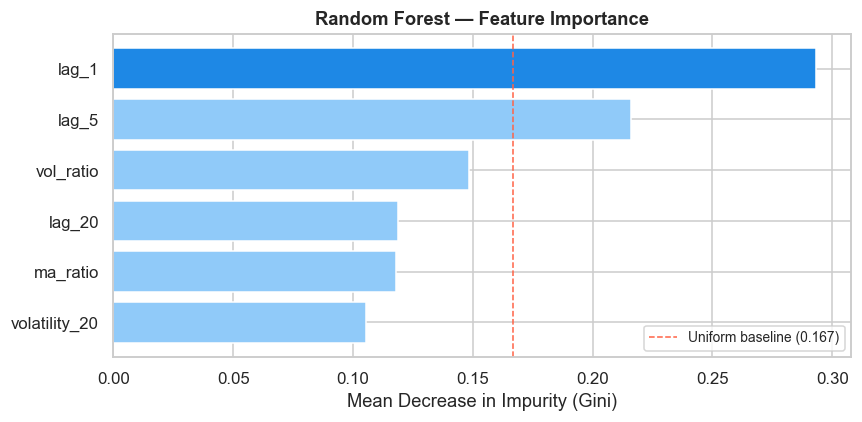

In [11]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ['#1E88E5' if v == importances.max() else '#90CAF9' for v in importances]
ax.barh(importances.index, importances.values, color=colors_fi)
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.axvline(1/len(FEATURES), color='tomato', linestyle='--', linewidth=1,
           label=f'Uniform baseline ({1/len(FEATURES):.3f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', bbox_inches='tight')
plt.show()


### Figure 3: Per-Sector Model Accuracy


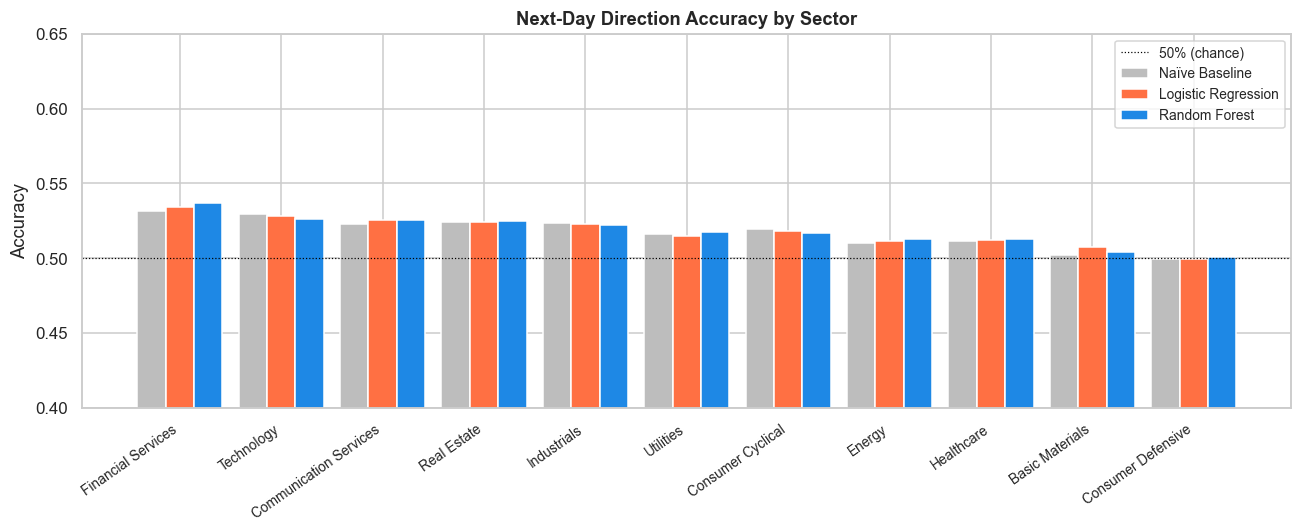

                        Random Forest  Logistic Regression  Naïve Baseline      n
sector                                                                           
Financial Services             0.5367               0.5342          0.5317  12246
Technology                     0.5260               0.5281          0.5298  11264
Communication Services         0.5253               0.5252          0.5228   5878
Real Estate                    0.5251               0.5240          0.5239   6368
Industrials                    0.5224               0.5231          0.5234  13021
Utilities                      0.5172               0.5150          0.5163   4408
Consumer Cyclical              0.5166               0.5178          0.5197   8816
Energy                         0.5129               0.5112          0.5100   2449
Healthcare                     0.5128               0.5118          0.5112   9960
Basic Materials                0.5042               0.5074          0.5022   3429
Consumer Defensi

In [12]:
sector_results = []
for sector, grp in test.groupby('sector'):
    if len(grp) < 200:
        continue
    Xs = scaler.transform(grp[FEATURES])
    y_s = grp['target']
    acc_rf = accuracy_score(y_s, rf.predict(grp[FEATURES]))
    acc_lr = accuracy_score(y_s, lr.predict(Xs))
    acc_naive = y_s.mean()   # always predict up = fraction of up days
    sector_results.append({'sector': sector,
                            'Random Forest': acc_rf,
                            'Logistic Regression': acc_lr,
                            'Naïve Baseline': acc_naive,
                            'n': len(grp)})

sr = pd.DataFrame(sector_results).set_index('sector').sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sr))
width = 0.28
ax.bar(x - width, sr['Naïve Baseline'], width, label='Naïve Baseline', color='#BDBDBD')
ax.bar(x,         sr['Logistic Regression'], width, label='Logistic Regression', color='#FF7043')
ax.bar(x + width, sr['Random Forest'], width, label='Random Forest', color='#1E88E5')
ax.axhline(0.5, color='black', linewidth=0.8, linestyle=':', label='50% (chance)')
ax.set_xticks(x)
ax.set_xticklabels(sr.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Next-Day Direction Accuracy by Sector', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.40, 0.65)
plt.tight_layout()
plt.savefig('figures/sector_accuracy.png', bbox_inches='tight')
plt.show()
print(sr[['Random Forest','Logistic Regression','Naïve Baseline','n']].round(4).to_string())


## Insights and Conclusions

### What we found

**1. Signal power is real but modest.**
The Random Forest consistently outperforms the naïve "always predict up" baseline, but the margin
is small — roughly 1–3 percentage points of accuracy above the baseline, with a ROC-AUC
noticeably above 0.50. This is consistent with decades of academic research on technical analysis:
simple signals contain *some* information, but markets are competitive enough that the edge is thin.
A reader should not expect to get rich from these signals alone.

**2. The most important features are short-term momentum and volatility.**
Feature importance rankings place `lag_1` (yesterday's return) and `volatility_20` (recent turbulence)
at the top. The moving-average ratio (`ma_ratio`) also contributes meaningfully, supporting the idea
that MA crossover signals carry at least weak predictive content. Volume ratio contributes the least —
while our EDA showed that high-volume days have bigger moves, volume alone does not reliably predict
*direction*.

**3. Sector matters.**
The per-sector accuracy chart shows meaningful variation. Some sectors (often in Technology or
Financials) show larger gaps between the RF model and the naïve baseline, suggesting their returns
are more systematic and less noisy. Defensive sectors like Utilities and Consumer Staples tend to
be harder to predict with these features, likely because their returns are driven more by
macroeconomic factors (interest rates, dividend expectations) than by momentum.

**4. Fat tails limit confidence.**
Analysis 1 showed that return distributions have excess kurtosis — extreme days occur far more
often than normality assumes. This means that even a model with decent average accuracy can suffer
large losses on rare but catastrophic days. Any practical application would need robust risk management.

### Limitations

- **No transaction costs:** In a real trading strategy, even a 1% predictive edge can vanish after
  bid/ask spreads and commissions.
- **Survivorship bias:** The dataset contains current S&P 500 constituents, which means we only see
  stocks that survived to the present — inherently excluding failures.
- **Non-stationarity:** Market dynamics change over time (COVID crash, rate cycles). A model trained
  pre-2020 behaves differently in 2022. A more rigorous study would use rolling or walk-forward
  validation.
- **Feature set:** This tutorial uses only six simple features. More sophisticated approaches add
  earnings data, macro indicators, NLP-derived sentiment, and inter-stock correlations.

### Conclusion

This tutorial demonstrated the complete data science pipeline on real financial data.
We showed that simple technical features carry statistically detectable (though modest) predictive
signal for next-day stock direction, that sector matters for model performance, and that no single
model should be trusted blindly given fat-tailed return distributions.
The project contributes a reproducible baseline that future analysts can extend with richer features,
longer history, or more sophisticated models.

---

### References

- Andrew MVD. *S&P 500 Stocks (daily updated).* Kaggle, 2024.
  https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks
- Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *Journal of Finance*, 25(2), 383–417.
- Lo, A. W., & MacKinlay, A. C. (1988). Stock market prices do not follow random walks. *Review of Financial Studies*, 1(1), 41–66.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Pandas Development Team. (2024). *pandas: powerful Python data analysis toolkit.* https://pandas.pydata.org
